# P(In Final Step | Occurred Before Final)
### Hallucination Type

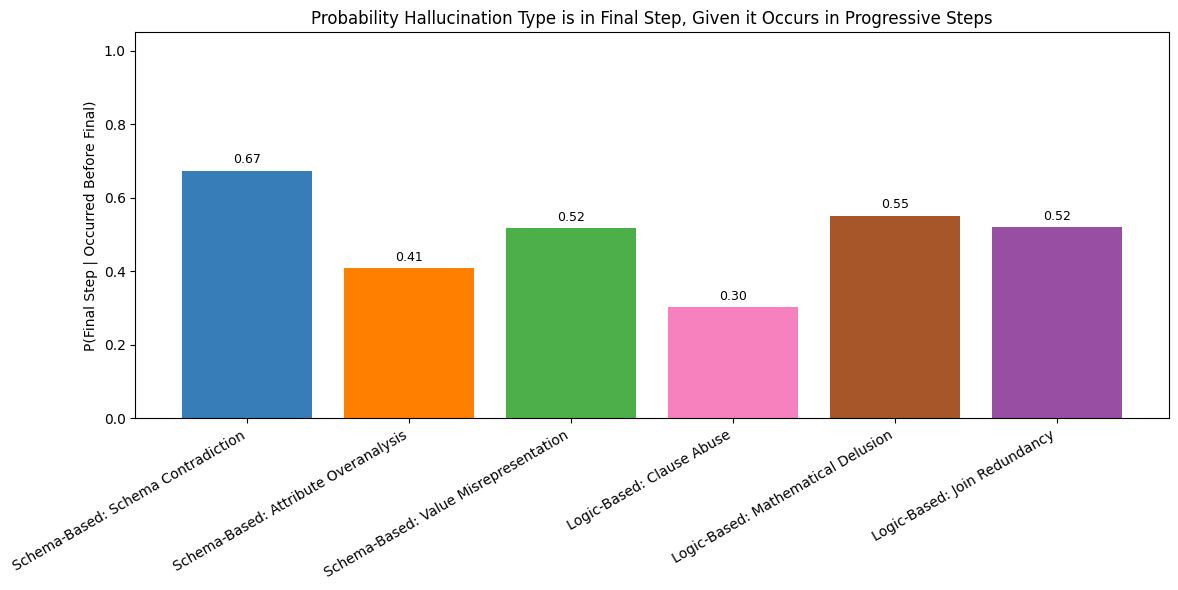

In [43]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))

before_final_counts = defaultdict(int)
before_and_final_counts = defaultdict(int)

# Count occurrences
for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    found_before_final = {ht: False for ht in hallucination_types}
    found_in_final = {ht: False for ht in hallucination_types}
    found_in_both = {ht: False for ht in hallucination_types}

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        types_in_step = {h[0] for h in hallucinations if isinstance(h, list) and h}

        for htype in hallucination_types:
            if htype in types_in_step:
                if i == len(path) - 1:
                    found_in_final[htype] = True
                else:
                    found_before_final[htype] = True
            if found_in_final[htype] and found_before_final[htype]:
                found_in_both[htype] = True

    for htype in hallucination_types:
        if found_before_final[htype]:
            before_final_counts[htype] += 1
        if found_in_both[htype]:
            before_and_final_counts[htype] += 1

# Compute conditional probabilities
conditional_probs = {
    htype: before_and_final_counts[htype] / before_final_counts[htype]
    if before_final_counts[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    conditional_probs.keys(),
    conditional_probs.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Final Step | Occurred Before Final)")
plt.title("Probability Hallucination Type is in Final Step, Given it Occurs in Progressive Steps")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)

# Annotate values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# P(Occurred Before Final | In Final Step)
### Hallucination Type

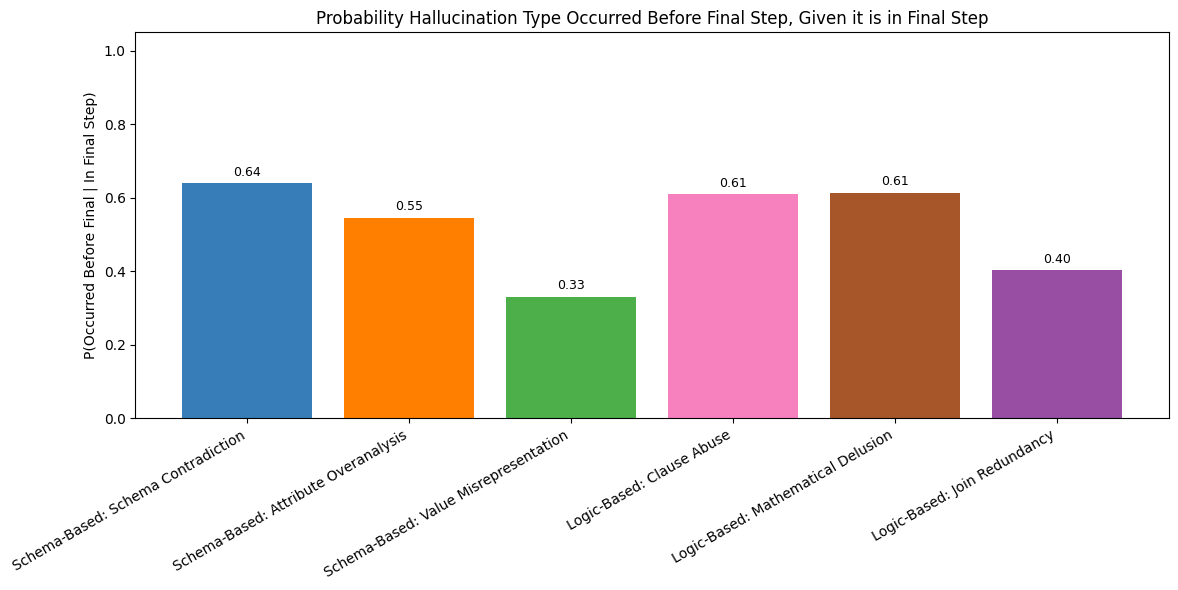

In [44]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))

in_final_counts = defaultdict(int)
before_and_final_counts = defaultdict(int)

# Count occurrences
for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    found_before_final = {ht: False for ht in hallucination_types}
    found_in_final = {ht: False for ht in hallucination_types}
    found_in_both = {ht: False for ht in hallucination_types}

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        types_in_step = {h[0] for h in hallucinations if isinstance(h, list) and h}

        for htype in hallucination_types:
            if htype in types_in_step:
                if i == len(path) - 1:
                    found_in_final[htype] = True
                else:
                    found_before_final[htype] = True
            if found_in_final[htype] and found_before_final[htype]:
                found_in_both[htype] = True

    for htype in hallucination_types:
        if found_in_final[htype]:
            in_final_counts[htype] += 1
        if found_in_both[htype]:
            before_and_final_counts[htype] += 1

# Compute conditional probabilities: P(Occurred Before Final | In Final Step)
conditional_probs = {
    htype: before_and_final_counts[htype] / in_final_counts[htype]
    if in_final_counts[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    conditional_probs.keys(),
    conditional_probs.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Occurred Before Final | In Final Step)")
plt.title("Probability Hallucination Type Occurred Before Final Step, Given it is in Final Step")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)

# Annotate values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# P(In Final Step | Occurred Before Final)
### Exact Same Hallucination

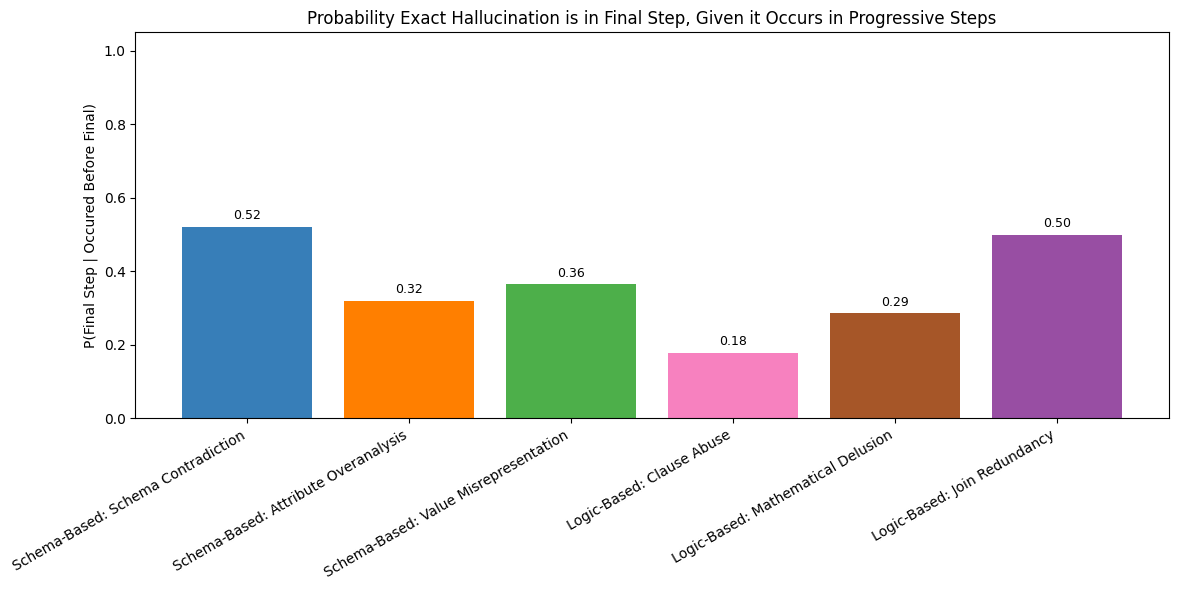

In [45]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))

before_final_counts = defaultdict(int)
before_and_final_counts = defaultdict(int)

# Count hallucinations (based on first two elements only)
for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev_halls_by_type = defaultdict(set)
    final_step_halls_by_type = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        # Only keep (type, explanation), ignoring the span/snippet
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                htype = h[0]
                final_step_halls_by_type[htype].add(h)
        else:
            for h in halluc_set:
                htype = h[0]
                all_prev_halls_by_type[htype].add(h)

    for htype in hallucination_types:
        prev = all_prev_halls_by_type[htype]
        final = final_step_halls_by_type[htype]

        if prev:
            before_final_counts[htype] += 1
        if prev & final:
            before_and_final_counts[htype] += 1

# Compute conditional probabilities
conditional_probs = {
    htype: before_and_final_counts[htype] / before_final_counts[htype]
    if before_final_counts[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    conditional_probs.keys(),
    conditional_probs.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Final Step | Occured Before Final)")
plt.title("Probability Exact Hallucination is in Final Step, Given it Occurs in Progressive Steps")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)

# Annotate values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# P(Occurred Before Final | In Final Step)
### Exact Same Hallucination

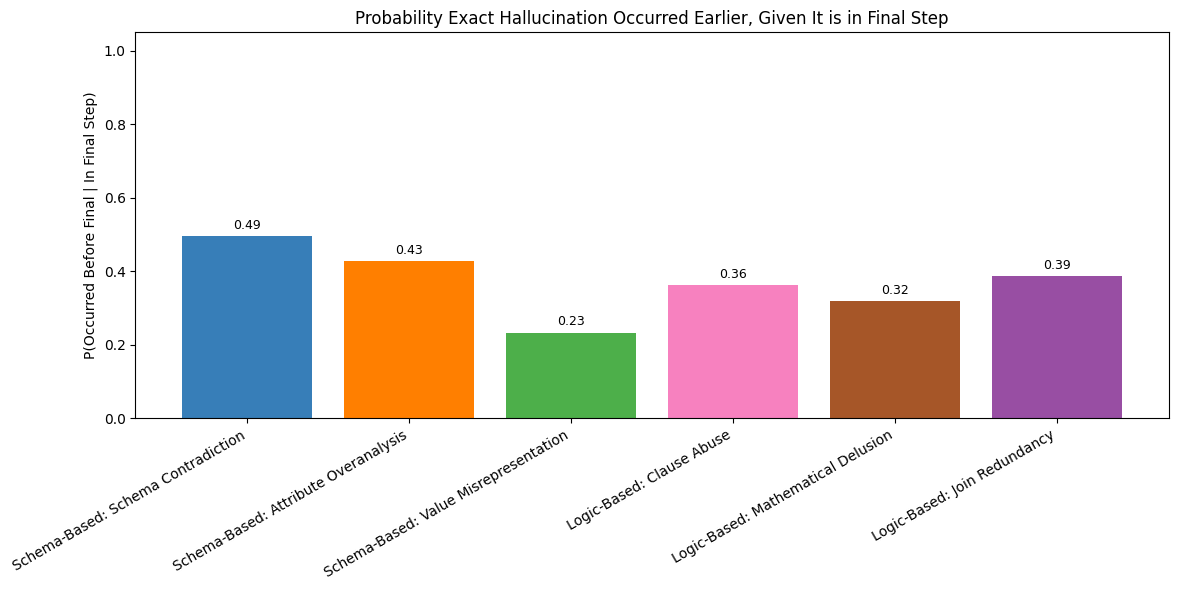

In [46]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))

in_final_counts = defaultdict(int)
before_and_final_counts = defaultdict(int)

# Count hallucinations (based on first two elements only)
for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev_halls_by_type = defaultdict(set)
    final_step_halls_by_type = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                htype = h[0]
                final_step_halls_by_type[htype].add(h)
        else:
            for h in halluc_set:
                htype = h[0]
                all_prev_halls_by_type[htype].add(h)

    for htype in hallucination_types:
        prev = all_prev_halls_by_type[htype]
        final = final_step_halls_by_type[htype]

        if final:
            in_final_counts[htype] += 1
        if prev & final:
            before_and_final_counts[htype] += 1

# Compute conditional probabilities
conditional_probs = {
    htype: before_and_final_counts[htype] / in_final_counts[htype]
    if in_final_counts[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    conditional_probs.keys(),
    conditional_probs.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Occurred Before Final | In Final Step)")
plt.title("Probability Exact Hallucination Occurred Earlier, Given It is in Final Step")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)

# Annotate values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# P(In Final Step | Doesnt Occur Before Final)
### Hallucination Type

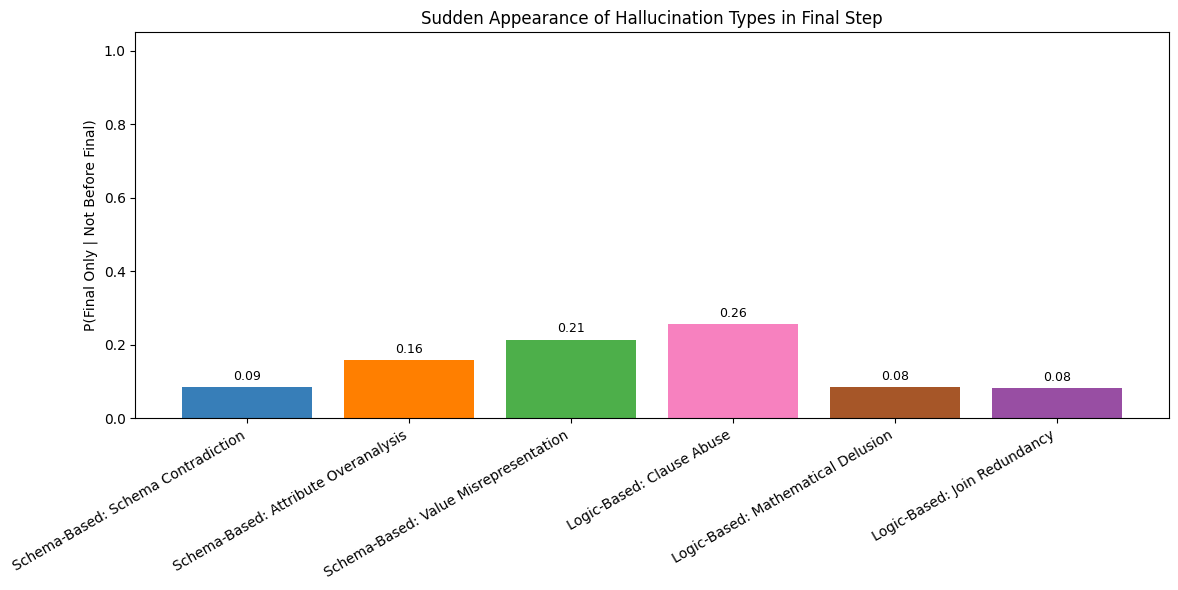

In [47]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))

only_final_counts = defaultdict(int)
not_before_final_counts = defaultdict(int)

# Count occurrences
for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    found_before_final = {ht: False for ht in hallucination_types}
    found_in_final = {ht: False for ht in hallucination_types}
    only_in_final = {ht: False for ht in hallucination_types}

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        types_in_step = {h[0] for h in hallucinations if isinstance(h, list) and h}

        for htype in hallucination_types:
            if htype in types_in_step:
                if i == len(path) - 1:
                    found_in_final[htype] = True
                else:
                    found_before_final[htype] = True

    for htype in hallucination_types:
        if found_in_final[htype] and not found_before_final[htype]:
            only_final_counts[htype] += 1
        if not found_before_final[htype]:
            not_before_final_counts[htype] += 1

# Compute conditional probabilities
final_only_given_not_before = {
    htype: only_final_counts[htype] / not_before_final_counts[htype]
    if not_before_final_counts[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    final_only_given_not_before.keys(),
    final_only_given_not_before.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Final Only | Not Before Final)")
plt.title("Sudden Appearance of Hallucination Types in Final Step")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)

# Annotate bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


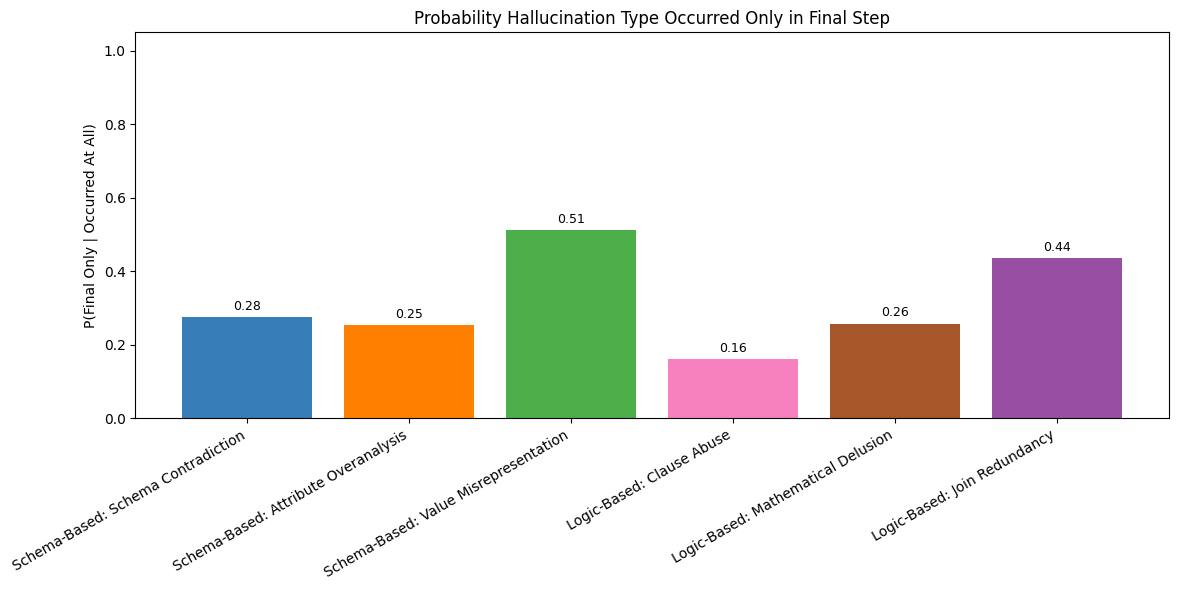

In [48]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load JSON
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))

only_final_counts = defaultdict(int)
total_occurrence_counts = defaultdict(int)

# Count occurrences
for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    found_before_final = {ht: False for ht in hallucination_types}
    found_in_final = {ht: False for ht in hallucination_types}

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        types_in_step = {h[0] for h in hallucinations if isinstance(h, list) and h}

        for htype in hallucination_types:
            if htype in types_in_step:
                if i == len(path) - 1:
                    found_in_final[htype] = True
                else:
                    found_before_final[htype] = True

    for htype in hallucination_types:
        if found_in_final[htype] or found_before_final[htype]:
            total_occurrence_counts[htype] += 1
        if found_in_final[htype] and not found_before_final[htype]:
            only_final_counts[htype] += 1

# Compute: P(Final Only | Occurred at all)
final_only_probs = {
    htype: only_final_counts[htype] / total_occurrence_counts[htype]
    if total_occurrence_counts[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    final_only_probs.keys(),
    final_only_probs.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Final Only | Occurred At All)")
plt.title("Probability Hallucination Type Occurred Only in Final Step")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)

# Annotate bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# P(In Final Step | Doesnt Occur Before Final)
### Exact Same Hallucination

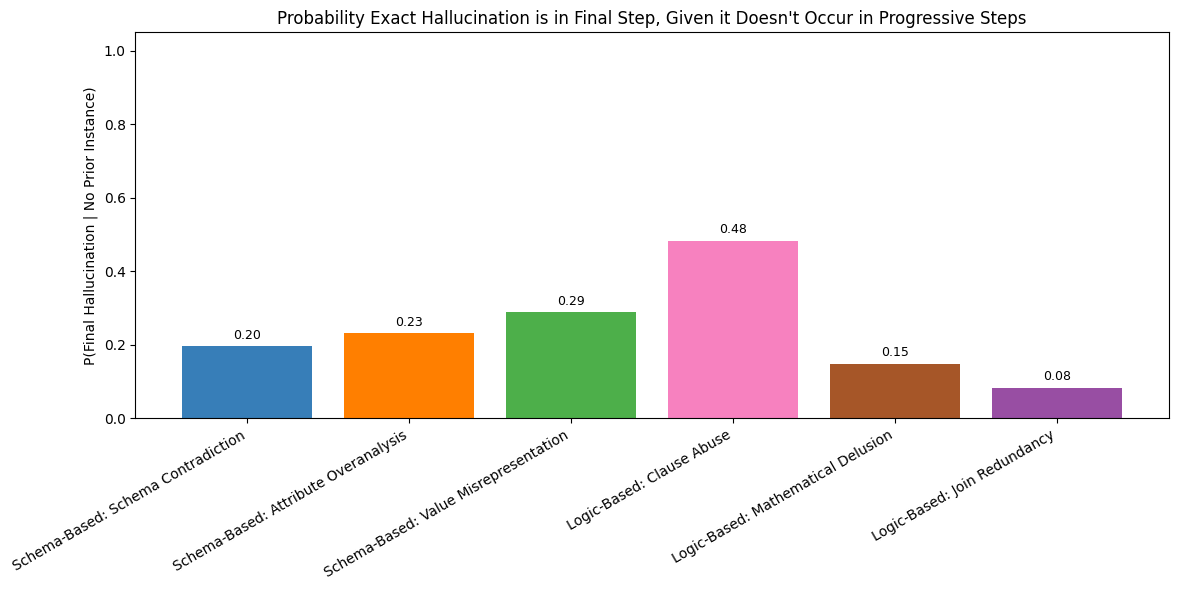

In [49]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# Load your JSON file
with open('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc_4_0.json', 'r') as f:
    data = json.load(f)

hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3']
color_map = dict(zip(hallucination_types, colors))

only_final_counts = defaultdict(int)
not_before_final_counts = defaultdict(int)

# Count based on (type, explanation) hallucinations
for entry in data:
    path = entry.get("path", [])
    if not path:
        continue

    all_prev_halls_by_type = defaultdict(set)
    final_step_halls_by_type = defaultdict(set)

    for i, step in enumerate(path):
        hallucinations = step.get("hallucination", [])
        halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

        if i == len(path) - 1:
            for h in halluc_set:
                htype = h[0]
                final_step_halls_by_type[htype].add(h)
        else:
            for h in halluc_set:
                htype = h[0]
                all_prev_halls_by_type[htype].add(h)

    for htype in hallucination_types:
        prev = all_prev_halls_by_type[htype]
        final = final_step_halls_by_type[htype]

        # Only count hallucinations in final that were not seen before
        unseen_in_prev = final - prev

        if unseen_in_prev:
            only_final_counts[htype] += 1
        if not prev:
            not_before_final_counts[htype] += 1

# Compute conditional probabilities
final_only_given_not_before = {
    htype: only_final_counts[htype] / not_before_final_counts[htype]
    if not_before_final_counts[htype] > 0 else 0
    for htype in hallucination_types
}

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    final_only_given_not_before.keys(),
    final_only_given_not_before.values(),
    color=[color_map[ht] for ht in hallucination_types]
)
plt.ylabel("P(Final Hallucination | No Prior Instance)")
plt.title("Probability Exact Hallucination is in Final Step, Given it Doesn't Occur in Progressive Steps")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)

# Annotate bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()
